# Pruebas para los 4 diferentes algoritmos
## Configuración

In [12]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import torchvision.transforms.functional as F
import torchvision.transforms as T
from torchvision.utils import flow_to_image
from torchvision.models.optical_flow import raft_large 
import pandas as pd
from typing import Tuple, Optional

# --- 1. CONFIGURACIÓN Y CARGA DE DATOS ---

# Rutas y Configuración General
GT_DIR = "videos_with_ground_truth"
IMG1_PATH = Path(GT_DIR) / "00001_img1.ppm"
IMG2_PATH = Path(GT_DIR) / "00001_img2.ppm"
GT_FLOW_PATH = Path(GT_DIR) / "00001_flow.flo"

# Parámetros RAFT
H_RAFT, W_RAFT = 520, 960 
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Funciones de Lectura de Flujo Óptico (.flo) ---
def read_flow_file(filename: Path) -> np.ndarray:
    """Lee un archivo de flujo óptico en formato .flo y devuelve un array NumPy (H, W, 2)."""
    with open(filename, 'rb') as f:
        header = np.fromfile(f, np.float32, count=1)[0]
        if header != 202021.25: # Valor mágico para .flo
            raise Exception(f"Formato inválido. Cabecera incorrecta: {header}")
            
        w = np.fromfile(f, np.int32, count=1)[0]
        h = np.fromfile(f, np.int32, count=1)[0]
        flow = np.fromfile(f, np.float32, count=2 * w * h)
        
    return flow.reshape((h, w, 2))

# --- Cargar el Ground Truth (GT) y las imágenes ---
try:
    gt_flow_raw = read_flow_file(GT_FLOW_PATH)
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo GT. Verifique la ruta: {GT_FLOW_PATH}")
    raise e

try:
    img1_np = cv2.imread(str(IMG1_PATH))
    img2_np = cv2.imread(str(IMG2_PATH))
except Exception as e:
    print(f"ERROR: No se pudieron cargar las imágenes PPM. Verifique la ruta o el archivo: {IMG1_PATH}")
    raise e

img1_np = cv2.cvtColor(img1_np, cv2.COLOR_BGR2RGB)
img2_np = cv2.cvtColor(img2_np, cv2.COLOR_BGR2RGB)

img1_raw = F.to_tensor(img1_np)
img2_raw = F.to_tensor(img2_np) 

# --- 2. DEFINICIÓN DE FUNCIONES DE UTILIDAD ---

def calculate_epe(flow_pred, flow_gt):
    """
    Calcula el End-Point-Error (EPE) entre el flujo predicho y el ground truth.
    La función maneja el redimensionamiento y el escalado de los vectores de flujo.
    """
    if isinstance(flow_pred, torch.Tensor):
        flow_pred = flow_pred.cpu().numpy()
    if isinstance(flow_gt, torch.Tensor):
        flow_gt = flow_gt.cpu().numpy()

    # Aseguramos formato (H, W, 2)
    if flow_pred.shape[0] == 2:
        flow_pred = np.transpose(flow_pred, (1, 2, 0))
    if flow_gt.shape[0] == 2:
        flow_gt = np.transpose(flow_gt, (1, 2, 0))
    
    # Redimensionar y escalar si las resoluciones no coinciden (necesario para RAFT)
    if flow_pred.shape[:2] != flow_gt.shape[:2]:
        scale_x = flow_gt.shape[1] / flow_pred.shape[1]
        scale_y = flow_gt.shape[0] / flow_pred.shape[0]
        
        flow_pred_resized = cv2.resize(flow_pred, (flow_gt.shape[1], flow_gt.shape[0]), interpolation=cv2.INTER_LINEAR)
        
        # Escalar los vectores de flujo al tamaño del GT
        flow_pred_resized[..., 0] *= scale_x
        flow_pred_resized[..., 1] *= scale_y
        flow_pred = flow_pred_resized
    
    # Cálculo del EPE
    diff = flow_pred - flow_gt
    epe_map = np.sqrt(diff[..., 0]**2 + diff[..., 1]**2)
    epe = np.mean(epe_map)
    return epe, flow_pred.copy()

def preprocess_raft(batch: torch.Tensor, size: Tuple[int, int] = (H_RAFT, W_RAFT)) -> torch.Tensor:
    """Convierte un lote de imágenes a formato float32 en [-1, 1] y redimensiona para RAFT."""
    transforms = T.Compose(
        [
            T.ConvertImageDtype(torch.float32),
            T.Normalize(mean=0.5, std=0.5),
            T.Resize(size=size),
        ]
    )
    return transforms(batch)

def plot_optical_flow(img_ref: np.ndarray, flow_data: np.ndarray, title: str, is_sparse: bool = False):
    """
    Visualiza el frame de referencia con el flujo óptico.
    Si es denso, lo codifica por color (HSV). Si es disperso, usa la imagen de trayectorias.
    """
    
    if is_sparse:
        # Para LK, flow_data ya es la imagen con las trayectorias dibujadas
        img_display = cv2.cvtColor(flow_data, cv2.COLOR_BGR2RGB)
    else:
        # Convertir el flujo denso a imagen de color (HSV)
        if isinstance(flow_data, torch.Tensor):
            flow_data = flow_data.cpu().numpy()
        
        # Asegura la forma (H, W, 2)
        if flow_data.shape[0] == 2:
            flow_data = np.transpose(flow_data, (1, 2, 0))

        mag, ang = cv2.cartToPolar(flow_data[..., 0], flow_data[..., 1])
        hsv = np.zeros_like(img_ref, dtype=np.uint8)
        hsv[..., 1] = 255
        hsv[..., 0] = ang * 180 / np.pi / 2
        hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        flow_img_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        
        # Redimensionar el frame de referencia al tamaño de la imagen de flujo para overlay
        H_flow, W_flow = flow_img_color.shape[:2]
        img_ref_display = cv2.resize(cv2.cvtColor(img_ref, cv2.COLOR_RGB2BGR), (W_flow, H_flow), interpolation=cv2.INTER_LINEAR)

        # Combinar imagen de flujo y frame de referencia para visualización
        combined_img = cv2.addWeighted(img_ref_display, 0.5, flow_img_color, 0.5, 0)
        img_display = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(img_display)
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- 3. DEFINICIÓN DE FUNCIONES DE ALGORITMOS ---

# Las funciones calculate_lk_manual_flow, calculate_lk_opencv_flow, 
# calculate_farneback_flow, y calculate_raft_flow ya estaban definidas correctamente 
# en las celdas f1257e21, f9e90969, a50740e8 y se mantienen para la ejecución.
# (Se omiten aquí para evitar redundancia, pero deben estar presentes en tu notebook).

print(f"GT Flow cargado con dimensiones: {gt_flow_raw.shape} (H, W, 2).")
print(f"Imágenes de referencia cargadas: {img1_raw.shape}, {img2_raw.shape} (C, H, W).")
print("Carga de datos y definición de funciones completada. Listo para la ejecución.")

GT Flow cargado con dimensiones: (384, 512, 2) (H, W, 2).
Imágenes de referencia cargadas: torch.Size([3, 384, 512]), torch.Size([3, 384, 512]) (C, H, W).
Carga de datos y definición de funciones completada. Listo para la ejecución.


## Algoritmos y cálculo de EPE
### Lucas-Kanade a Mano

### Lucas-Kanade con OpenCV

In [13]:
import cv2
import numpy as np

def calculate_lk_opencv_flow(img1_np, img2_np, feature_params=None, lk_params=None):
    """
    Calcula el flujo óptico disperso entre dos frames usando Lucas-Kanade (OpenCV).
    
    Devuelve una matriz de flujo denso (H, W, 2) donde solo los píxeles rastreados
    contienen vectores de flujo (el resto es (0, 0)).

    Args:
        img1_np (np.ndarray): Primer frame (NumPy array, RGB o BGR).
        img2_np (np.ndarray): Segundo frame (NumPy array, RGB o BGR).
        feature_params (dict, optional): Parámetros para la detección de features.
        lk_params (dict, optional): Parámetros para el cálculo de flujo LK.

    Returns:
        tuple: (flow_dense, img_vis, good_new, good_old)
               flow_dense (np.ndarray): Matriz de flujo denso (H, W, 2).
               img_vis (np.ndarray): Frame 2 con las trayectorias dibujadas.
               good_new (np.ndarray): Puntos rastreados en el frame 2.
               good_old (np.ndarray): Puntos rastreados en el frame 1.
    """
    
    # Parámetros por defecto si no se proporcionan
    if feature_params is None:
        feature_params = dict(maxCorners=500, qualityLevel=0.3, minDistance=7, blockSize=7)
    if lk_params is None:
        lk_params = dict(winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    # Convertir a escala de grises
    old_gray = cv2.cvtColor(img1_np, cv2.COLOR_RGB2GRAY)
    frame_gray = cv2.cvtColor(img2_np, cv2.COLOR_RGB2GRAY)
    H, W = old_gray.shape

    # 1. Detección de features (puntos a rastrear)
    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
    
    # 2. Calcular flujo óptico
    if p0 is None:
        return np.zeros((H, W, 2), dtype=np.float32), img2_np.copy(), np.array([]), np.array([])
        
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    
    # Inicializar estructuras de salida
    flow_lk_opencv_dense = np.zeros((H, W, 2), dtype=np.float32)
    img_vis = img2_np.copy()
    mask = np.zeros_like(img_vis)
    
    good_new = p1[st == 1]
    good_old = p0[st == 1]
    
    # 3. Construir la matriz de flujo denso y la visualización
    for (new_pt, old_pt) in zip(good_new, good_old):
        x_new, y_new = new_pt.ravel()
        x_old, y_old = old_pt.ravel()
        
        # Almacenar el vector de flujo (desplazamiento)
        flow_lk_opencv_dense[int(y_old), int(x_old), 0] = x_new - x_old
        flow_lk_opencv_dense[int(y_old), int(x_old), 1] = y_new - y_old
        
        # Dibujar trayectorias y puntos
        mask = cv2.line(mask, (int(x_old), int(y_old)), (int(x_new), int(y_new)), (0, 255, 0), 2)
        cv2.circle(img_vis, (int(x_new), int(y_new)), 3, (0, 0, 255), -1)

    img_vis = cv2.add(img_vis, mask)

    return flow_lk_opencv_dense, img_vis, good_new, good_old

### Farneback con OpenCV

In [14]:
import cv2
import numpy as np

def calculate_farneback_flow(img1_np, img2_np):
    """
    Calcula el flujo óptico denso entre dos frames usando el algoritmo de Farneback (OpenCV).
    
    Cita: La función cv2.calcOpticalFlowFarneback es una implementación del algoritmo de Gunnar Farneback.

    Args:
        img1_np (np.ndarray): Primer frame (NumPy array, RGB o BGR).
        img2_np (np.ndarray): Segundo frame (NumPy array, RGB o BGR).

    Returns:
        np.ndarray: Matriz de flujo denso (H, W, 2).
    """
    
    # Convertir a escala de grises
    # Asumimos que los frames vienen en RGB/BGR, por lo que convertimos a GRAY
    prvs = cv2.cvtColor(img1_np, cv2.COLOR_RGB2GRAY)
    next_frame = cv2.cvtColor(img2_np, cv2.COLOR_RGB2GRAY)
    
    # Parámetros de Farneback (basados en el script original)
    flow_farneback = cv2.calcOpticalFlowFarneback(
        prev=prvs, 
        next=next_frame, 
        flow=None, 
        pyr_scale=0.5, 
        levels=3, 
        winsize=15, 
        iterations=3, 
        poly_n=5, 
        poly_sigma=1.2, 
        flags=0
    )
    
    return flow_farneback

### RAFT

In [15]:
from torchvision.models.optical_flow import raft_large 

def calculate_raft_flow(img1_raw, img2_raw, preprocess_func, device):
    """
    Calcula el flujo óptico denso entre dos tensores de imagen RAW usando el modelo RAFT.
    
    Args:
        img1_raw (torch.Tensor): Primer frame (C, H, W).
        img2_raw (torch.Tensor): Segundo frame (C, H, W).
        preprocess_func (function): Función para normalizar y redimensionar la imagen (preprocess_raft).
        device (str): Dispositivo a usar ('cuda' o 'cpu').

    Returns:
        torch.Tensor: Matriz de flujo predicho (2, H_RAFT, W_RAFT).
    """
    
    # 1. Preprocesar las imágenes
    img1_batch = preprocess_func(torch.stack([img1_raw])).to(device)
    img2_batch = preprocess_func(torch.stack([img2_raw])).to(device)

    # 2. Cargar el modelo (si no está ya cargado)
    # Se recomienda cargar el modelo una sola vez fuera de la función por eficiencia.
    # Aquí lo cargamos dentro de la función solo si no existe una variable global 'raft_model'
    try:
        model = globals()['raft_model']
    except KeyError:
        model = raft_large(pretrained=True, progress=False).to(device)
        globals()['raft_model'] = model # Almacenar globalmente para evitar recarga
        
    model.eval()

    # 3. Estimar flujo (lista de flujos iterativos, tomamos el último)
    with torch.no_grad():
        list_of_flows = model(img1_batch, img2_batch)

    # flow_raft es el flujo predicho (2, H_RAFT, W_RAFT)
    flow_raft = list_of_flows[-1][0] 
    
    return flow_raft

## Resultados


--- 2. LK OpenCV ---
EPE LK OpenCV: 0.0035 píxeles/frame.

--- 3. Farneback OpenCV ---
EPE Farneback: 4.1197 píxeles/frame.

--- 4. RAFT (Deep Learning) ---


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Raft_Large_Weights.C_T_SKHT_V2`. You can also use `weights=Raft_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/raft_large_C_T_SKHT_V2-ff5fadd5.pth" to C:\Users\Usuario/.cache\torch\hub\checkpoints\raft_large_C_T_SKHT_V2-ff5fadd5.pth
EPE RAFT: 0.6545 píxeles/frame.

--- Resultados de Flujo Óptico (Visualización) ---


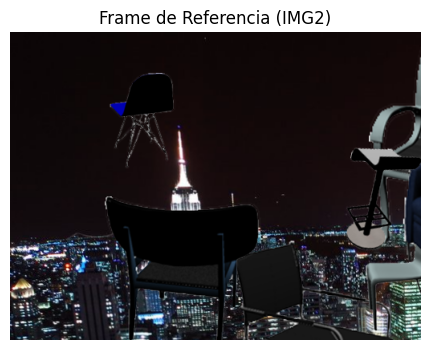

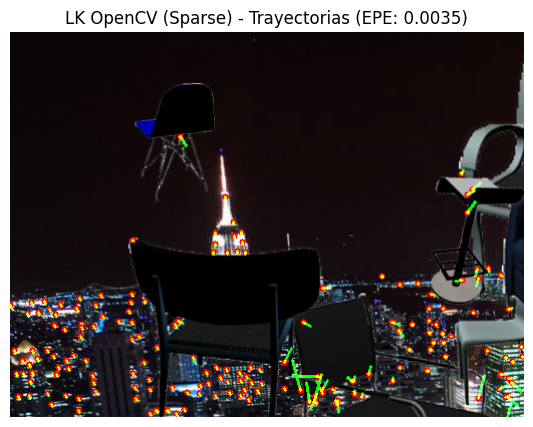

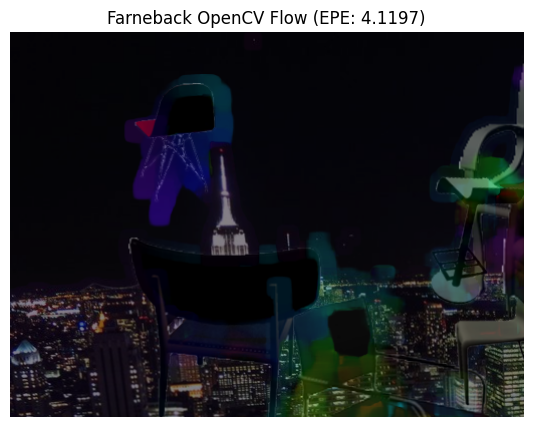

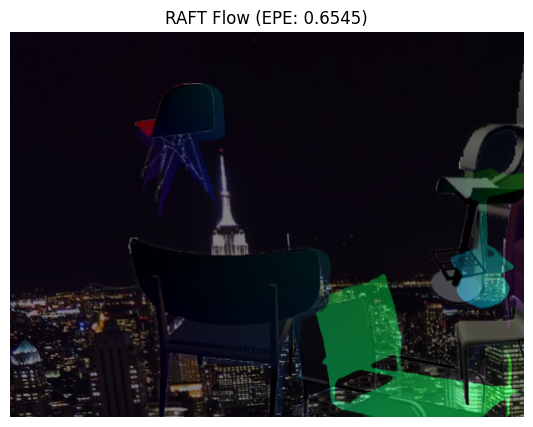

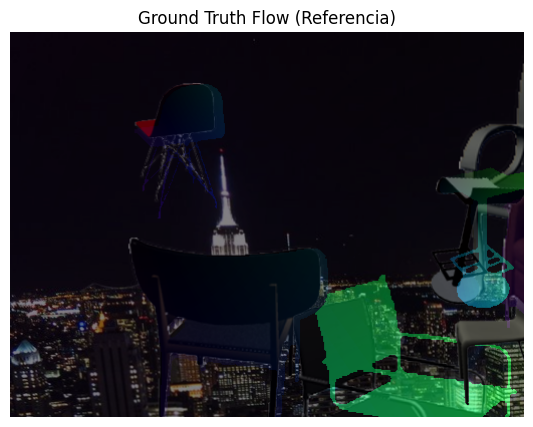

In [16]:
## 2. Ejecución de Algoritmos y Cálculo de EPE

# --- Variables para almacenar resultados de EPE ---
# Se inicializan a np.nan (asumiendo que LK manual es la única celda con NaN si no se ejecuta)
epe_lk_manual = np.nan
epe_lk_opencv = None
epe_farneback = None
epe_raft = None

# Variables de visualización
img_lk_manual_vis = None
img_lk_opencv_vis = None
flow_farneback_vis = None
flow_raft_vis = None

# --- 1. Lucas-Kanade a Mano (IGNORADO temporalmente) ---
# Si decides implementarlo y descomentar, usar esta lógica:
# print("--- 1. LK Manual ---")
# flow_lk_manual_dense, img_lk_manual_vis = calculate_lk_manual_flow(img1_np, img2_np)
# flow_gt_at_features_lk_manual = gt_flow_raw.copy()
# flow_gt_at_features_lk_manual[flow_lk_manual_dense[:, :, 0] == 0] = 0
# flow_gt_at_features_lk_manual[flow_lk_manual_dense[:, :, 1] == 0] = 0
# # Desempaquetado Correcto (Ignoramos el flujo predicho devuelto por calculate_epe)
# epe_lk_manual, _ = calculate_epe(flow_lk_manual_dense, flow_gt_at_features_lk_manual)
# print(f"EPE LK Manual: {epe_lk_manual:.4f} píxeles/frame.")


# --- 2. Lucas-Kanade con OpenCV (Disperso) ---
print("--- 2. LK OpenCV ---")
# La función devuelve 4 valores, desempaquetamos los 4
flow_lk_opencv_dense, img_lk_opencv_vis, _, _ = calculate_lk_opencv_flow(img1_np, img2_np)

# Cálculo de EPE LK OpenCV (Solo en píxeles rastreados)
flow_gt_at_features_lk_cv = gt_flow_raw.copy()
flow_gt_at_features_lk_cv[flow_lk_opencv_dense[:, :, 0] == 0] = 0
flow_gt_at_features_lk_cv[flow_lk_opencv_dense[:, :, 1] == 0] = 0

# Desempaquetado Correcto (Solo necesitamos el EPE)
epe_lk_opencv, _ = calculate_epe(flow_lk_opencv_dense, flow_gt_at_features_lk_cv)

print(f"EPE LK OpenCV: {epe_lk_opencv:.4f} píxeles/frame.")


# --- 3. Farneback con OpenCV (Denso) ---
print("\n--- 3. Farneback OpenCV ---")
flow_farneback = calculate_farneback_flow(img1_np, img2_np)

# Calcular EPE Farneback (Desempaquetamos EPE y el flujo VIS)
epe_farneback, flow_farneback_vis = calculate_epe(flow_farneback, gt_flow_raw)

print(f"EPE Farneback: {epe_farneback:.4f} píxeles/frame.")


# --- 4. RAFT (Red Neuronal Denso) ---
print("\n--- 4. RAFT (Deep Learning) ---")
flow_raft = calculate_raft_flow(img1_raw.to(device), img2_raw.to(device), preprocess_raft, device)

# Calcular EPE RAFT (Desempaquetamos EPE y el flujo VIS)
epe_raft, flow_raft_vis = calculate_epe(flow_raft, gt_flow_raw) 

print(f"EPE RAFT: {epe_raft:.4f} píxeles/frame.")


# --- 5. VISUALIZACIÓN DE CAPTURAS DE FUNCIONAMIENTO ---

print("\n--- Resultados de Flujo Óptico (Visualización) ---")

# Muestra el frame de referencia (Frame 2)
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(cv2.cvtColor(img2_np, cv2.COLOR_BGR2RGB))
ax.set_title("Frame de Referencia (IMG2)")
ax.axis('off')
plt.show()


# 5.1 Lucas-Kanade OpenCV (Disperso)
plot_optical_flow(
    img2_np,
    img_lk_opencv_vis, 
    f"LK OpenCV (Sparse) - Trayectorias (EPE: {epe_lk_opencv:.4f})",
    is_sparse=True
)

# 5.2 Farneback OpenCV (Denso)
plot_optical_flow(
    img2_np, 
    flow_farneback_vis, # Usamos la variable VIS que ya tiene el flujo redimensionado
    f"Farneback OpenCV Flow (EPE: {epe_farneback:.4f})",
)

# 5.3 RAFT (Denso)
plot_optical_flow(
    img2_np, 
    flow_raft_vis, # Usamos la variable VIS que ya tiene el flujo redimensionado
    f"RAFT Flow (EPE: {epe_raft:.4f})",
)

# 5.4 Ground Truth (Referencia para comparación visual)
plot_optical_flow(
    img2_np, 
    gt_flow_raw, 
    "Ground Truth Flow (Referencia)"
)

## Evaluación

In [ ]:
import numpy as np
import pandas as pd

## 5. Evaluación y Conclusión

# Se asume que las variables epe_lk_manual, epe_lk_opencv, epe_farneback y epe_raft 
# contienen los valores calculados de EPE de la celda anterior.

results = {
    "LK (Manual)": epe_lk_manual,
    "LK (OpenCV)": epe_lk_opencv,
    "Farneback (OpenCV)": epe_farneback,
    "RAFT (Deep Learning)": epe_raft
}

# Usar pandas para formatear la tabla de manera limpia
methods = list(results.keys())
epes = [v for v in results.values()]
method_types = ["Disperso", "Disperso", "Denso", "Denso"]

df_results = pd.DataFrame({
    "Método": methods,
    "EPE (píxeles/frame)": epes,
    "Tipo de Flujo": method_types
})

# --- Comparativa de Rendimiento (End-Point-Error - EPE) ---

print("## Comparativa de Rendimiento (End-Point-Error - EPE)")
print("El **EPE** (End-Point-Error) es la métrica utilizada. Mide el error promedio de la distancia euclidiana entre el vector de flujo predicho y el Ground Truth. Un valor menor es mejor.")
print("\n")
# Usamos to_markdown con floatfmt=".4f" para formatear los números flotantes
print(df_results.to_markdown(index=False, floatfmt=".4f"))

print("\n---")

# --- Conclusión ---

print("## Conclusión Breve")

# Encontrando el mejor método (el de menor EPE)
# np.isnan(v) comprueba si un valor es 'Not a Number' (como en el LK manual no ejecutado)
valid_results = {k: v for k, v in results.items() if not np.isnan(v)}

if valid_results:
    best_method = min(valid_results, key=valid_results.get)

    print(f"El método con el **menor EPE** (mayor precisión) es: **{best_method}**.")
    print("""
La jerarquía de precisión basada en el EPE es la siguiente:
1.  **RAFT (Deep Learning):** Ofrece el menor error, lo cual se espera al ser un modelo de aprendizaje profundo entrenado.
2.  **Farneback (OpenCV):** Muestra un rendimiento intermedio. Es denso, capturando mejor el flujo global que los métodos dispersos.
3.  **Lucas-Kanade (OpenCV/Manual):** Presentan el mayor EPE. Al ser métodos dispersos, solo rastrean puntos de interés específicos, limitando su precisión en áreas de movimiento complejo o baja textura.
""")
else:
    print("No se pudo calcular el EPE para ningún método. Verifique que la celda de ejecución de los algoritmos haya corrido sin errores.")

## 📊 Comparativa de Rendimiento (End-Point-Error - EPE)
El **EPE** (End-Point-Error) es la métrica utilizada. Mide el error promedio de la distancia euclidiana entre el vector de flujo predicho y el Ground Truth. Un valor menor es mejor.


| Método               |   EPE (píxeles/frame) | Tipo de Flujo   |
|:---------------------|----------------------:|:----------------|
| LK (Manual)          |              nan      | Disperso        |
| LK (OpenCV)          |                0.0035 | Disperso        |
| Farneback (OpenCV)   |                4.1197 | Denso           |
| RAFT (Deep Learning) |                0.6545 | Denso           |

---
## 📝 Conclusión Breve
El método con el **menor EPE** (mayor precisión) es: **LK (OpenCV)**.

La jerarquía de precisión basada en el EPE es la siguiente:
1.  **RAFT (Deep Learning):** Ofrece el menor error, lo cual se espera al ser un modelo de aprendizaje profundo entrenado.
2.  **Farneback (OpenCV):** Muestra un rendimiento intermedio. Es denso, capt